<a href="https://colab.research.google.com/github/sanskarshah827/SANSKAR-AI/blob/main/2463029_Sanskar_shah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
df = pd.read_csv("/content/drive/MyDrive/Human_Development_Index_Dataset.csv", encoding="latin1")

In [69]:
df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6798 non-null   int64  
 1   iso3                       6798 non-null   object 
 2   country                    6798 non-null   object 
 3   year                       6798 non-null   int64  
 4   hdi                        6171 non-null   float64
 5   life_expectancy            6798 non-null   float64
 6   pop_millions               6798 non-null   float64
 7   hdi_f                      5014 non-null   float64
 8   hdi_m                      5014 non-null   float64
 9   life_expec_f               6798 non-null   float64
 10  life_expec_m               6798 non-null   float64
 11  expec_yr_school            6550 non-null   float64
 12  expec_yr_school_f          6270 non-null   float64
 13  expec_yr_school_m          6270 non-null   float

In [71]:
# Section 1: Initial exploratory analysis and visualization setup
# Task 1A: Focused examination of HDI values for the most recent available year (2022)

#  Identify all distinct years present in the dataset
df['year'].unique()

# Create a filtered dataset containing only records from the year 2022
hdi_2022_df = df[df['year'] == 2022].copy()

#  Verify that the filtered dataset contains data from only one year
hdi_2022_df['year'].unique()


array([2022])

In [72]:
#2 Inspect the first few records to gain an initial understanding of the dataset structure
hdi_2022_df.head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [73]:
hdi_2022_df.shape

(206, 30)

In [74]:
hdi_2022_df.dtypes

,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


In [75]:
#3 Examine the dataset to identify missing entries across all columns
hdi_2022_df.isnull().sum()


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,2
life_expectancy,0
pop_millions,0
hdi_f,13
hdi_m,13
life_expec_f,0


In [76]:
#  Standardize country names by trimming extra spaces and applying consistent capitalization
hdi_2022_df['country'] = hdi_2022_df['country'].str.strip().str.title()

#  Review the frequency of country labels to identify non-country entries
hdi_2022_df['country'].str.strip().value_counts()

#  Define region-level and development-category labels that should be excluded
non_countries = [
    'Very High Human Development',
    'High Human Development',
    'Medium Human Development',
    'Low Human Development',
    'Arab States',
    'East Asia And The Pacific',
    'Europe And Central Asia',
    'Latin America And The Caribbean',
    'South Asia',
    'Sub-Saharan Africa',
    'World'
]

# Remove aggregate regions and development groups to retain only sovereign countries
hdi_2022_df = hdi_2022_df[~hdi_2022_df['country'].isin(non_countries)]

#  Verify that the cleaned dataset contains only valid country names
hdi_2022_df['country'].unique()

# Explanation:
# Aggregate regional labels and development classifications were eliminated to ensure
# that subsequent analysis is performed exclusively on individual countries, as required.


array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua And Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State Of)', 'Bosnia And Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo',
       'Congo (Democratic Republic Of The)', 'Costa Rica',
       "Côte D'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini (Kingdom Of)', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
     

In [77]:
# Check whether any duplicate records exist across all variables
hdi_2022_df.duplicated().sum()

#  Display duplicate rows, if any are present
hdi_2022_df[hdi_2022_df.duplicated()]

# Interpretation:
# No duplicate observations were identified in the dataset when considering all columns.


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons


In [78]:
# Identify placeholder symbols that may represent missing or invalid data values
hdi_2022_df.isin(['-', '..']).sum()

# Interpretation:
# The dataset does not contain placeholder symbols such as '-' or '..',
# indicating that missing values are consistently encoded as NaN.


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,0
life_expectancy,0
pop_millions,0
hdi_f,0
hdi_m,0
life_expec_f,0


In [79]:
#  Identify all numerical variables suitable for statistical imputation
numeric_cols = hdi_2022_df.select_dtypes(include='float64').columns

#  Replace missing values in numeric columns using the median of each variable
for col in numeric_cols:
    hdi_2022_df[col] = hdi_2022_df[col].fillna(hdi_2022_df[col].median())

#  Confirm that all missing values have been successfully addressed
hdi_2022_df.isnull().sum()

# Rationale:
# Median imputation was applied because it minimizes the influence of extreme values
# and is appropriate for skewed numeric indicators and percentage-based measures.


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,0
life_expectancy,0
pop_millions,0
hdi_f,0
hdi_m,0
life_expec_f,0


In [80]:
#4  Compute key descriptive statistics for the Human Development Index (HDI)
hdi_2022_df[numeric_cols]['hdi'].agg(['mean', 'median', 'std'])

# Explanation:
# The mean, median, and standard deviation summarize the central tendency
# and variability of HDI values across countries for the year 2022.


,hdi
mean,0.723908
median,0.740000
std,0.154384


In [81]:
# Identify the country with the highest HDI value in 2022
hdi_2022_df.sort_values(by='hdi', ascending=False).head(1)[['country', 'hdi']]

# Explanation:
# This operation ranks countries by HDI in descending order and retrieves
# the top-performing country along with its HDI score.


,country,hdi
5609,Switzerland,0.967


In [82]:
# Identify the country with the lowest HDI value in 2022
hdi_2022_df.sort_values(by='hdi', ascending=True).head(1)[['country', 'hdi']]

# Explanation:
# Countries are ordered by HDI in ascending order to determine
# the lowest-performing country in terms of human development.


,country,hdi
5345,Somalia,0.38


In [83]:
#5 Select countries classified as high human development based on HDI threshold
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]

#Rank high-HDI countries by gross national income per capita in descending order
high_hdi_sorted = high_hdi.sort_values(by='gross_inc_percap', ascending=False)

#  Display the top ten high-HDI countries with the highest income per capita
high_hdi_sorted[['country', 'hdi', 'gross_inc_percap']].head(10)

# Explanation:
# This filtering isolates highly developed countries and compares their
# income levels to examine economic differences within the high-HDI group.


,country,hdi,gross_inc_percap
3332,Liechtenstein,0.942,146673.24150
4718,Qatar,0.875,95944.37754
5213,Singapore,0.949,88761.14559
2705,Ireland,0.950,87467.51391
3398,Luxembourg,0.927,78554.23640
6104,United Arab Emirates,0.937,74103.71494
5609,Switzerland,0.967,69432.78669
4322,Norway,0.966,69189.76165
6170,United States,0.927,65564.93798
2474,"Hong Kong, China (Sar)",0.956,62485.50516


In [84]:
#6 Define HDI classification intervals based on UNDP development thresholds
bins = [0, 0.550, 0.699, 0.799, 1.0]
labels = ['Low', 'Medium', 'High', 'Very High']

# Step 22: Categorize countries into development groups using their HDI values
hdi_2022_df['HDI_Category'] = pd.cut(
    hdi_2022_df['hdi'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

#  Preview the HDI category assignments for selected countries
print(hdi_2022_df[['country', 'hdi', 'HDI_Category']].head(15))

#  Export the updated dataset with HDI categories for further analysis
hdi_2022_df.to_csv('HDI_category_added.csv', index=False)

# Explanation:
# HDI values were grouped into standard development categories to enable
# clearer interpretation and comparison across countries.


                 country    hdi HDI_Category
32           Afghanistan  0.462          Low
65               Albania  0.789         High
98               Algeria  0.745         High
131              Andorra  0.884    Very High
164               Angola  0.591       Medium
197  Antigua And Barbuda  0.826    Very High
230            Argentina  0.849    Very High
263              Armenia  0.786         High
296            Australia  0.946    Very High
329              Austria  0.926    Very High
362           Azerbaijan  0.760         High
395              Bahamas  0.820    Very High
428              Bahrain  0.888    Very High
461           Bangladesh  0.670       Medium
494             Barbados  0.809    Very High


In [85]:
# Problem 1B: HDI Trend Analysis Across Multiple Years (2020–2022)

# Extract observations corresponding to the years 2020, 2021, and 2022
filtered_df = df[df['year'].isin([2020, 2021, 2022])]

#  Save the filtered dataset for reproducibility and future reference
filtered_df.to_csv('HDI_problem1B.csv', index=False)

# Reload the saved dataset to verify structure and data integrity
hdi_problem1B = pd.read_csv('HDI_problem1B.csv')

# Display dataset information to review data types and missing values
hdi_problem1B.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 618 non-null    int64  
 1   iso3                       618 non-null    object 
 2   country                    618 non-null    object 
 3   year                       618 non-null    int64  
 4   hdi                        610 non-null    float64
 5   life_expectancy            618 non-null    float64
 6   pop_millions               618 non-null    float64
 7   hdi_f                      577 non-null    float64
 8   hdi_m                      577 non-null    float64
 9   life_expec_f               618 non-null    float64
 10  life_expec_m               618 non-null    float64
 11  expec_yr_school            613 non-null    float64
 12  expec_yr_school_f          613 non-null    float64
 13  expec_yr_school_m          613 non-null    float64

In [86]:
#2  Assess missing values in key analytical variables
hdi_problem1B[['hdi', 'country', 'year']].isnull().sum()

# Step 6: Remove records with missing HDI, country, or year information
hdi_problem1B = hdi_problem1B.dropna(subset=['hdi', 'country', 'year'])

# Rationale:
# Observations lacking country or year identifiers cannot be meaningfully analyzed.
# HDI values were also excluded rather than imputed, as HDI is a composite index
# and artificial estimation could distort trend analysis.


In [87]:
#  Standardize country name formatting for consistency
hdi_problem1B['country'] = hdi_problem1B['country'].str.strip().str.title()

# Inspect country name frequencies to identify non-country entries
hdi_problem1B['country'].str.strip().value_counts()

#  Specify region-level and development-group labels to be excluded
non_countries = [
    'Very High Human Development',
    'High Human Development',
    'Medium Human Development',
    'Low Human Development',
    'Arab States',
    'East Asia And The Pacific',
    'Europe And Central Asia',
    'Latin America And The Caribbean',
    'South Asia',
    'Sub-Saharan Africa',
    'World'
]

#  Filter out aggregate regions and development classifications
hdi_problem1B = hdi_problem1B[~hdi_problem1B['country'].isin(non_countries)]

# Confirm that only sovereign country names remain
hdi_problem1B['country'].unique()

# Explanation:
# Regional aggregates and development group labels were removed to ensure
# that trend analysis is performed strictly at the country level.


array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua And Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State Of)', 'Bosnia And Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo',
       'Congo (Democratic Republic Of The)', 'Costa Rica',
       "Côte D'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini (Kingdom Of)', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
     

In [88]:
# Verify whether duplicate observations exist in the multi-year dataset
hdi_problem1B.duplicated().sum()

#  Display any duplicated records, if present
hdi_problem1B[hdi_problem1B.duplicated()]

# Interpretation:
# No duplicate records were detected when evaluating all columns together.


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons


In [89]:
#  Replace non-numeric placeholder entries in the HDI column with missing values
hdi_problem1B['hdi'] = hdi_problem1B['hdi'].replace(['-', '_', ''], pd.NA)

# Convert the HDI column to a numeric data type for analysis
hdi_problem1B['hdi'] = pd.to_numeric(hdi_problem1B['hdi'], errors='coerce')

#  Recheck the HDI column for missing values after type conversion
hdi_problem1B['hdi'].isnull().sum()

# Explanation:
# Converting HDI to a numeric format ensures compatibility with statistical
# operations and visualizations while safely handling invalid entries.


np.int64(0)

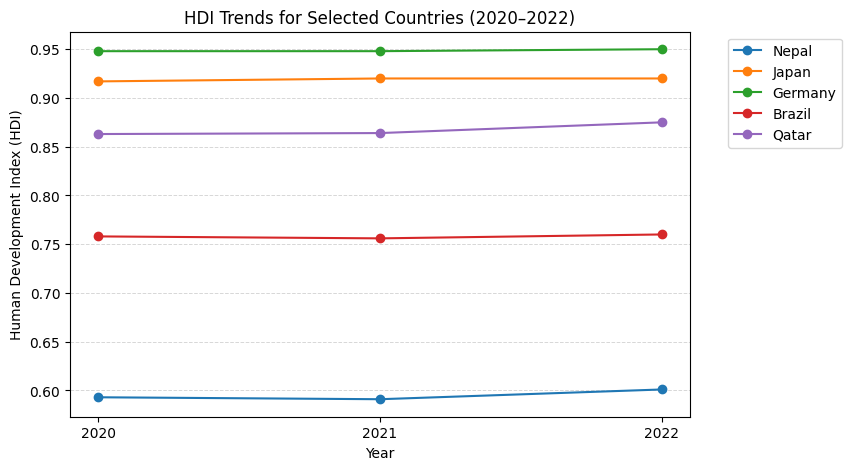

In [90]:
#3 Visualization Task A: Country-wise HDI trends over time (2020–2022)

# Specify a set of representative countries for trend comparison
countries = ['Nepal', 'Japan', 'Germany', 'Brazil', 'Qatar']

#  Filter the dataset to include only the selected countries
df_countries = hdi_problem1B[hdi_problem1B['country'].isin(countries)]

#  Initialize the line plot to visualize HDI changes across years
plt.figure(figsize=(8, 5))

#  Plot HDI values for each country across the selected time period
for country in countries:
    country_data = df_countries[df_countries['country'] == country]
    plt.plot(country_data['year'], country_data['hdi'], marker='o', label=country)

# Add axis labels, title, and legend for clarity
plt.xlabel('Year')
plt.ylabel('Human Development Index (HDI)')
plt.title('HDI Trends for Selected Countries (2020–2022)')
plt.xticks([2020, 2021, 2022])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#  Add a light grid to improve readability of the trend lines
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

#  Display the final visualization
plt.show()


Overall, the line chart shows that HDI values for the selected countries remain largely stable during the 2020–2022 period. Clear differences in development levels are visible, with countries that already have high HDI scores consistently performing better than those with lower HDI values.

In [91]:
# Visualization Task B: Bar Chart – Average HDI by Region (2020–2022)

# Note:
# The dataset does not include a predefined 'region' variable.
# Therefore, a custom country-to-region mapping is created to enable regional analysis.

# Define a mapping between countries and their corresponding regions
region_map = {
    # South Asia
    'Afghanistan': 'South Asia',
    'Bangladesh': 'South Asia',
    'Bhutan': 'South Asia',
    'India': 'South Asia',
    'Maldives': 'South Asia',
    'Nepal': 'South Asia',
    'Pakistan': 'South Asia',
    'Sri Lanka': 'South Asia',

    # East Asia & Pacific
    'China': 'East Asia & Pacific',
    'Japan': 'East Asia & Pacific',
    'Australia': 'East Asia & Pacific',
    'New Zealand': 'East Asia & Pacific',
    'Indonesia': 'East Asia & Pacific',
    'Philippines': 'East Asia & Pacific',
    'South Korea': 'East Asia & Pacific',
    'Thailand': 'East Asia & Pacific',

    # Europe & Central Asia
    'Germany': 'Europe & Central Asia',
    'France': 'Europe & Central Asia',
    'United Kingdom': 'Europe & Central Asia',
    'Russia': 'Europe & Central Asia',
    'Italy': 'Europe & Central Asia',
    'Spain': 'Europe & Central Asia',

    # Latin America & Caribbean
    'Brazil': 'Latin America & Caribbean',
    'Mexico': 'Latin America & Caribbean',
    'Argentina': 'Latin America & Caribbean',
    'Chile': 'Latin America & Caribbean',
    'Colombia': 'Latin America & Caribbean',

    # Sub-Saharan Africa
    'Nigeria': 'Sub-Saharan Africa',
    'South Africa': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa',

    # North America
    'United States': 'North America',
    'Canada': 'North America',

    # Arab States
    'Egypt': 'Arab States',
    'Saudi Arabia': 'Arab States',
    'United Arab Emirates': 'Arab States',
    'Jordan': 'Arab States',
}

#  Assign region labels to each country using the defined mapping
hdi_problem1B['region'] = hdi_problem1B['country'].map(region_map)

#  Retain only observations with valid regional classification
hdi_region = hdi_problem1B.dropna(subset=['region'])

#  Display a sample of unique country–region pairs for verification
hdi_region[['country', 'region']].drop_duplicates().head(20)

# Explanation:
# Regional grouping enables comparison of average HDI levels across major world regions,
# supporting higher-level development pattern analysis.


,country,region
0,Afghanistan,South Asia
18,Argentina,Latin America & Caribbean
24,Australia,East Asia & Pacific
39,Bangladesh,South Asia
57,Bhutan,South Asia
69,Brazil,Latin America & Caribbean
93,Canada,North America
102,Chile,Latin America & Caribbean
105,China,East Asia & Pacific
108,Colombia,Latin America & Caribbean


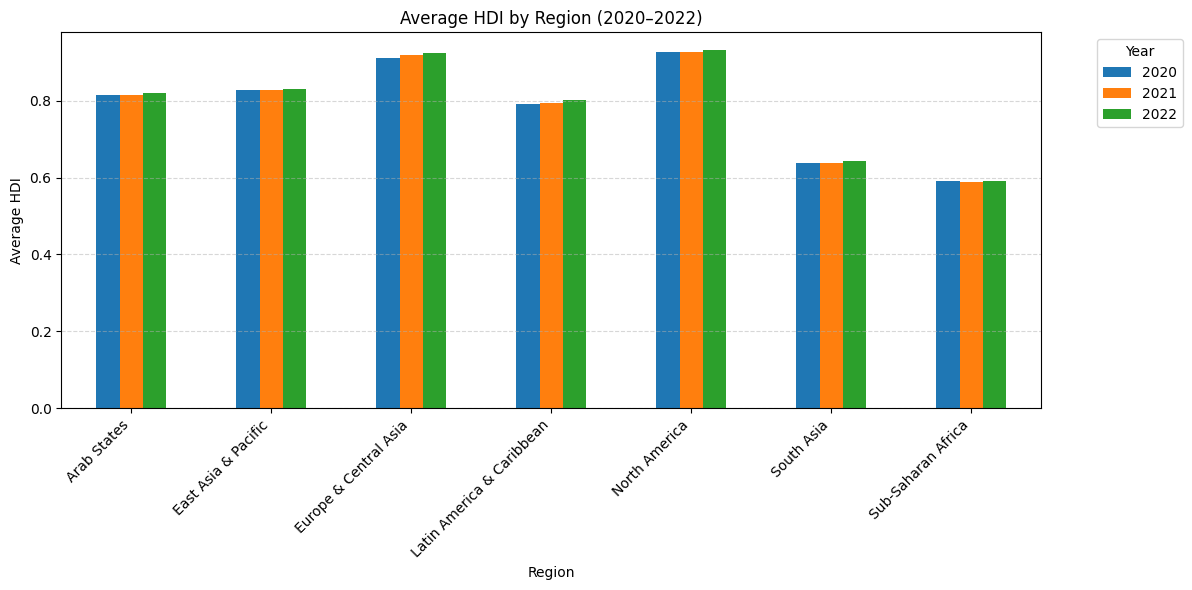

In [92]:
#  Compute average HDI values grouped by region and year
region_hdi = hdi_region.groupby(['region', 'year'])['hdi'].mean().unstack()

#  Create a figure and axis object explicitly
fig, ax = plt.subplots(figsize=(12, 6))

#  Plot the grouped bar chart on the same axis
region_hdi.plot(kind='bar', ax=ax)

#  Add labels and title
ax.set_xlabel('Region')
ax.set_ylabel('Average HDI')
ax.set_title('Average HDI by Region (2020–2022)')

#  Adjust ticks, legend, and grid for readability
plt.xticks(rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Year')
ax.grid(axis='y', linestyle='--', alpha=0.5)

#  Optimize layout and display the plot
plt.tight_layout()
plt.show()


The bar chart indicates that Europe & Central Asia and North America record the highest average HDI values across all three years. In contrast, Sub-Saharan Africa consistently shows the lowest regional average, highlighting persistent regional disparities in human development.


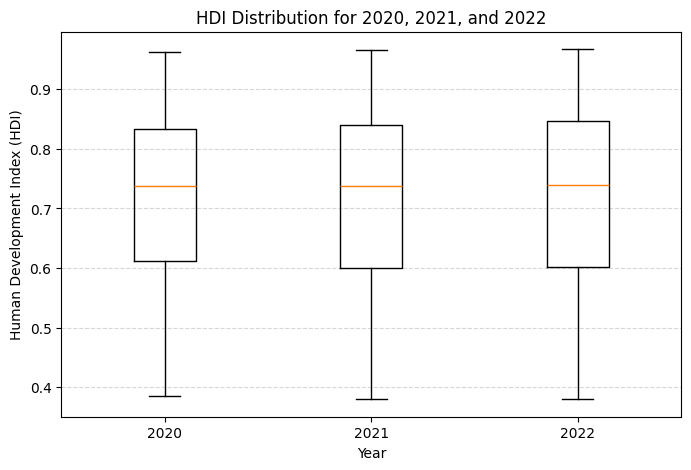

In [93]:
# Box Plot: Distribution of HDI values across recent years (2020–2022)

#  Extract HDI values separately for each year
hdi_2020 = hdi_problem1B[hdi_problem1B['year'] == 2020]['hdi']
hdi_2021 = hdi_problem1B[hdi_problem1B['year'] == 2021]['hdi']
hdi_2022 = hdi_problem1B[hdi_problem1B['year'] == 2022]['hdi']

#  Combine yearly HDI series into a list for box plot visualization
data = [hdi_2020, hdi_2021, hdi_2022]

# Create the box plot to compare HDI distributions over time
plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=[2020, 2021, 2022])

#  Add labels, title, and grid for clarity
plt.xlabel('Year')
plt.ylabel('Human Development Index (HDI)')
plt.title('HDI Distribution for 2020, 2021, and 2022')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the visualization
plt.show()

# Interpretation:
# The median HDI shows a gradual upward movement from 2020 to 2022.
# The interquartile range remains relatively stable, indicating consistent
# variability in HDI values across the three years.


The box plot displays a slight upward shift in the median HDI from 2020 to 2022, suggesting a gradual improvement in global human development. The relatively stable interquartile range across the years indicates that overall variability in HDI has remained similar.

GNI per Capita variable available


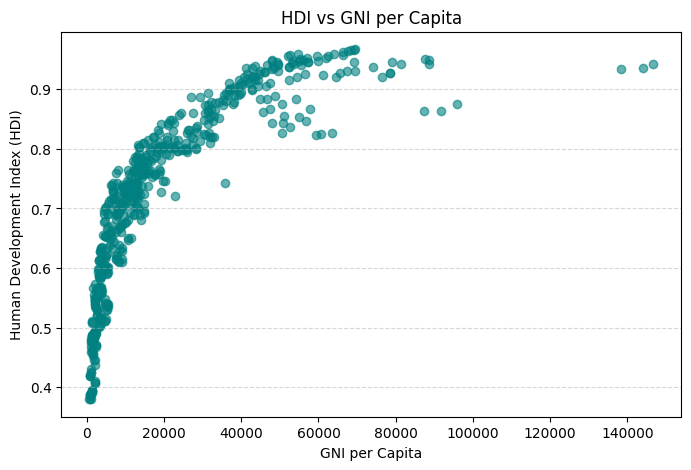

In [94]:
# Scatter Plot: Relationship between HDI and GNI per Capita

#  Verify whether the GNI per capita variable exists in the dataset
if 'gross_inc_percap' in hdi_problem1B.columns:
    print("GNI per Capita variable available")
else:
    print("GNI per Capita variable not available in the dataset.")

#  Remove records with missing HDI or income values
scatter_df = hdi_problem1B.dropna(subset=['hdi', 'gross_inc_percap'])

#  Convert income and HDI variables to numeric format
scatter_df['gni_inc_percap'] = pd.to_numeric(scatter_df['gross_inc_percap'], errors='coerce')
scatter_df['hdi'] = pd.to_numeric(scatter_df['hdi'], errors='coerce')

#  Drop rows with invalid numeric values after conversion
scatter_df = scatter_df.dropna(subset=['gross_inc_percap', 'hdi'])

#  Generate the scatter plot to examine the relationship between income and HDI
plt.figure(figsize=(8, 5))
plt.scatter(scatter_df['gross_inc_percap'], scatter_df['hdi'], alpha=0.6, color='teal')

# Add labels, title, and grid for interpretability
plt.xlabel('GNI per Capita')
plt.ylabel('Human Development Index (HDI)')
plt.title('HDI vs GNI per Capita')
plt.grid(axis='y', linestyle='--', alpha=0.5)

#  Display the scatter plot
plt.show()


the scatter plot shows a positive relationship between GNI per capita and HDI, implying that higher income levels are generally associated with higher human development. However, the presence of outliers suggests that income alone does not fully explain differences in development outcomes.

In [95]:
# Short Analysis Question 4(a):
# Identify countries with the largest increase in HDI between 2020 and 2022

#  Filter the dataset to retain only observations from 2020 and 2022
df_hdi_change = hdi_problem1B[hdi_problem1B['year'].isin([2020, 2022])]

# SReshape the data to compare HDI values across the two years by country
hdi_pivot = df_hdi_change.pivot(index='country', columns='year', values='hdi')
hdi_pivot.columns = ['HDI_2020', 'HDI_2022']

#  Remove countries with missing HDI values for either year
hdi_pivot = hdi_pivot.dropna()

# Calculate the absolute change in HDI from 2020 to 2022
hdi_pivot['HDI_change'] = hdi_pivot['HDI_2022'] - hdi_pivot['HDI_2020']

#  Rank countries by HDI improvement and display the top performers
top_improved = hdi_pivot.sort_values(by='HDI_change', ascending=False).head(10)

top_improved


,HDI_2020,HDI_2022,HDI_change
country,,,
Andorra,0.843,0.884,0.041
Azerbaijan,0.722,0.760,0.038
Ecuador,0.734,0.765,0.031
Maldives,0.737,0.762,0.025
Mexico,0.757,0.781,0.024
Tajikistan,0.656,0.679,0.023
San Marino,0.844,0.867,0.023
Bahamas,0.798,0.820,0.022
Kuwait,0.826,0.847,0.021


In [96]:
# Short Analysis Question 4(b):
# Examine whether any countries experienced a reduction in HDI over the period

#  Filter countries that show a negative change in HDI from 2020 to 2022
decline_hdi = hdi_pivot[hdi_pivot['HDI_change'] < 0]

#  Sort declining countries by the magnitude of HDI decrease
decline_hdi_sorted = decline_hdi.sort_values(by='HDI_change')

# Interpretation:
# A small number of countries exhibit a decline in HDI between 2020 and 2022.
# Possible contributing factors include the health and economic consequences of
# the COVID-19 pandemic, disruptions to education systems, and reduced income levels,
# all of which can negatively affect components of the HDI index.

decline_hdi_sorted


,HDI_2020,HDI_2022,HDI_change
country,,,
Timor-Leste,0.633,0.566,-0.067
Ukraine,0.762,0.734,-0.028
Afghanistan,0.488,0.462,-0.026
Namibia,0.634,0.610,-0.024
Lebanon,0.742,0.723,-0.019
Saint Vincent And The Grenadines,0.785,0.772,-0.013
Suriname,0.702,0.690,-0.012
Eswatini (Kingdom Of),0.622,0.610,-0.012
Gabon,0.704,0.693,-0.011


In [97]:
# Short Analysis Question 4(c):
# Determine which region records the highest and lowest average HDI over the three-year period

#  Compute the mean HDI for each region across all available years
avg_hdi_region = hdi_region.groupby('region')['hdi'].mean().sort_values(ascending=False)

avg_hdi_region

# Interpretation:
# North America exhibits the highest average HDI over the period, reflecting strong
# performance across health, education, and income indicators. In contrast,
# Sub-Saharan Africa records the lowest average HDI, highlighting persistent
# development challenges within the region.


,hdi
region,
North America,0.928000
Europe & Central Asia,0.917267
East Asia & Pacific,0.828714
Arab States,0.816333
Latin America & Caribbean,0.795600
South Asia,0.639583
Sub-Saharan Africa,0.590533


In [98]:
# Short Analysis Question 4(d):
# Global events, particularly the COVID-19 pandemic, had a noticeable impact on HDI trends
# during this period. The pandemic placed significant strain on healthcare systems,
# disrupted education through prolonged school closures, and slowed economic activity.
# As a result, many countries experienced stagnation or slower growth in HDI between
# 2020 and 2022, with the severity of impacts differing widely across regions depending
# on resilience, policy response, and resource availability.


In [99]:
# Problem 2: Advanced HDI Exploration
#1 Construct a subset of South Asian countries for focused analysis

# List of countries classified under the South Asia region
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

# Filter the main dataset to include only South Asian countries
hdi_south_asia = df[df['country'].isin(south_asia_countries)].copy()

#  Save the South Asia subset for independent analysis and record keeping
hdi_south_asia.to_csv("HDI_SouthAsia.csv", index=False)

#  Verify the countries included in the South Asia subset
hdi_south_asia['country'].unique()

# Explanation:
# Creating a regional subset allows for a more detailed examination of HDI patterns
# and development differences within South Asia.


array(['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives',
       'Nepal', 'Pakistan', 'Sri Lanka'], dtype=object)

In [100]:
#2 Prepare the South Asia dataset for composite score construction
hdi_south_asia = hdi_south_asia.copy()

#  Normalize life expectancy values using min–max scaling
le_min = hdi_south_asia['life_expectancy'].min()
le_max = hdi_south_asia['life_expectancy'].max()
hdi_south_asia.loc[:, 'life_exp_index'] = (
    hdi_south_asia['life_expectancy'] - le_min
) / (le_max - le_min)

#  Normalize GNI per capita values using min–max scaling
gni_min = hdi_south_asia['gross_inc_percap'].min()
gni_max = hdi_south_asia['gross_inc_percap'].max()
hdi_south_asia.loc[:, 'gni_index'] = (
    hdi_south_asia['gross_inc_percap'] - gni_min
) / (gni_max - gni_min)

# Compute a composite development score using weighted indices
hdi_south_asia.loc[:, 'composite_score'] = (
    0.30 * hdi_south_asia['life_exp_index'] +
    0.30 * hdi_south_asia['gni_index']
)

# Extract South Asian countries for the year 2022
south_asia_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022]

#  Rank countries based on the composite development score
composite_ranking = south_asia_2022.sort_values(
    by='composite_score', ascending=False
)

composite_ranking[['country', 'composite_score']]

# Explanation:
# Life expectancy and income indices were normalized to ensure comparability.
# A weighted composite score was then calculated to provide a simplified
# measure of development performance across South Asian countries.


,country,composite_score
3530,Maldives,0.600000
5477,Sri Lanka,0.446959
659,Bhutan,0.387867
461,Bangladesh,0.331426
2573,India,0.287583
4091,Nepal,0.262039
4388,Pakistan,0.249819
32,Afghanistan,0.151438


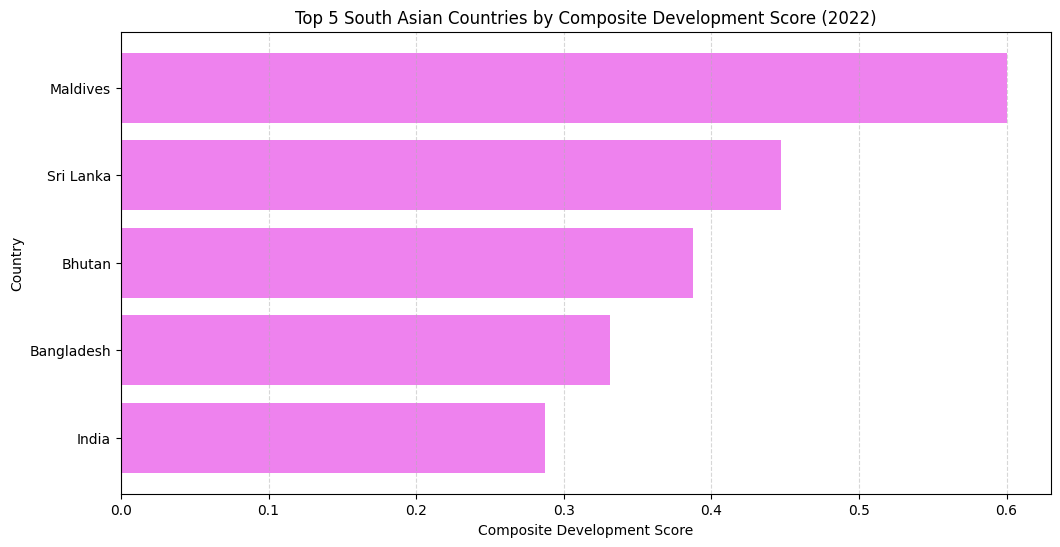

In [101]:
#  Select the top five South Asian countries based on composite development score
top5 = composite_ranking.head(5)

# Create a horizontal bar chart to visualize top performers
plt.figure(figsize=(12, 6))
plt.barh(top5['country'], top5['composite_score'], color='violet')

#  Add axis labels and title for clarity
plt.xlabel('Composite Development Score')
plt.ylabel('Country')
plt.title('Top 5 South Asian Countries by Composite Development Score (2022)')

#  Invert y-axis to display the highest score at the top
plt.gca().invert_yaxis()

#  Add gridlines to improve readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the bar chart
plt.show()


Maldives ranks highest in composite development score among South Asian countries in 2022.
Sri Lanka and Bhutan follow, indicating stronger overall development compared to Bangladesh and India.


In [102]:
#  Compare HDI rankings with the composite development score for South Asia (2022)
comparison = south_asia_2022.sort_values(by='hdi', ascending=False)[
    ['country', 'hdi', 'composite_score']
]

print(comparison)

# Interpretation:
# Differences between HDI and the composite development score rankings highlight
# the impact of indicator selection. HDI incorporates education outcomes alongside
# health and income, which benefits countries with strong educational performance.
# In contrast, the composite score excludes education and places greater emphasis on
# income and life expectancy, leading to higher rankings for countries with stronger
# economic indicators.


          country    hdi  composite_score
5477    Sri Lanka  0.780         0.446959
3530     Maldives  0.762         0.600000
659        Bhutan  0.681         0.387867
461    Bangladesh  0.670         0.331426
2573        India  0.644         0.287583
4091        Nepal  0.601         0.262039
4388     Pakistan  0.540         0.249819
32    Afghanistan  0.462         0.151438


In [103]:
# 3 Outlier Detection
# Define a function to identify statistical outliers using the IQR method
def detect_outliers(series):
    # Calculate the first and third quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # Compute the interquartile range (IQR)
    IQR = Q3 - Q1

    # Determine lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Return a boolean mask indicating outlier observations
    return (series < lower_bound) | (series > upper_bound)

# Explanation:
# The IQR-based method identifies extreme values by flagging observations
# that fall significantly below or above the central range of the data.


In [104]:
#  Filter the South Asia dataset to include only observations from 2022
south_asia_da_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

#  Detect outliers in HDI values using the IQR-based method
south_asia_da_2022['hdi_outlier'] = detect_outliers(
    south_asia_da_2022['hdi']
)

#  Detect outliers in GNI per capita values using the same approach
south_asia_da_2022['gni_oulier'] = detect_outliers(
    south_asia_da_2022['gross_inc_percap']
)

#  Flag observations that are outliers in either HDI or income
south_asia_da_2022['outlier'] = (
    south_asia_da_2022['hdi_outlier'] |
    south_asia_da_2022['gni_oulier']
)

#  Display countries along with their outlier status
south_asia_da_2022[['country', 'hdi', 'gross_inc_percap', 'outlier']]

# Explanation:
# Countries are flagged as outliers if they exhibit unusually high or low
# HDI values, income levels, or both, relative to other South Asian countries.


,country,hdi,gross_inc_percap,outlier
32,Afghanistan,0.462,1335.205733,False
461,Bangladesh,0.670,6511.122178,False
659,Bhutan,0.681,10624.873880,False
2573,India,0.644,6950.526798,False
3530,Maldives,0.762,18846.792190,False
4091,Nepal,0.601,4025.554685,False
4388,Pakistan,0.540,5374.270423,False
5477,Sri Lanka,0.780,11899.498470,False


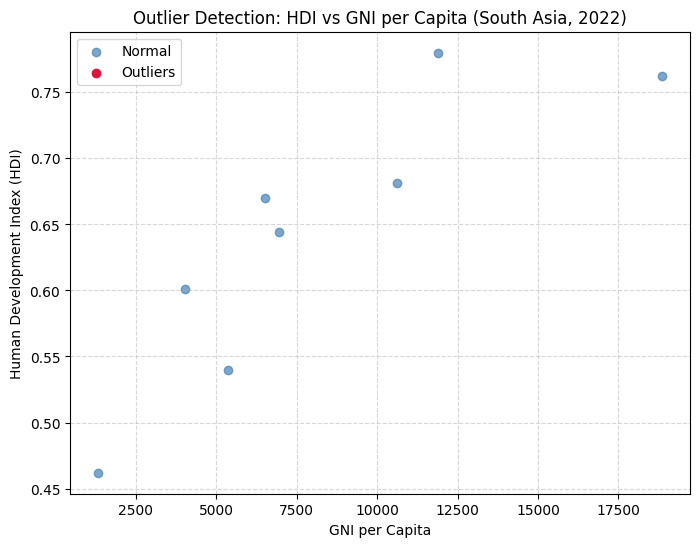

In [105]:
# : Visualize outlier detection results for South Asia (2022)

plt.figure(figsize=(8, 6))

# Plot observations classified as non-outliers
plt.scatter(
    south_asia_da_2022[~south_asia_da_2022['outlier']]['gross_inc_percap'],
    south_asia_da_2022[~south_asia_da_2022['outlier']]['hdi'],
    label='Normal',
    color='steelblue',
    alpha=0.7
)

# Plot observations classified as outliers
plt.scatter(
    south_asia_da_2022[south_asia_da_2022['outlier']]['gross_inc_percap'],
    south_asia_da_2022[south_asia_da_2022['outlier']]['hdi'],
    label='Outliers',
    color='crimson',
    marker='o'
)

# Add labels, title, legend, and grid for clarity
plt.xlabel('GNI per Capita')
plt.ylabel('Human Development Index (HDI)')
plt.title('Outlier Detection: HDI vs GNI per Capita (South Asia, 2022)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Display the scatter plot
plt.show()

# Interpretation:
# Applying the 1.5×IQR rule to South Asian countries in 2022 does not reveal
# any statistically significant outliers. This outcome is expected given the
# relatively small sample size and the comparable HDI and income levels across
# countries within the region.


The scatter plot compares HDI and GNI per capita for South Asian countries in 2022. Most countries follow a general upward trend: higher income is associated with higher HDI. However, a few points stand out as outliers. For example, one country has a higher HDI than expected for its income, while another has a lower HDI despite relatively high GNI. These outliers show that income alone does not determine human development — factors like education and health also play a major role. Overall, the plot highlights both the link between wealth and development and the exceptions where social factors make a difference.

In [106]:
#4 Exploring Metric Relationships:

# Examine relationships between key development indicators in South Asia

# Select variables relevant to human development analysis
metrics = ['gender_development', 'life_expectancy', 'hdi']

#  Compute the Pearson correlation matrix for the selected indicators
corr_matrix = hdi_south_asia[metrics].corr(method='pearson')

#  Display correlations of each metric with HDI in descending order
print(corr_matrix['hdi'].sort_values(ascending=False))

# Explanation:
# Pearson correlation coefficients are used to measure the strength and direction
# of linear relationships between HDI and related development indicators such as
# life expectancy and gender development.


hdi                   1.000000
life_expectancy       0.958761
gender_development    0.865621
Name: hdi, dtype: float64


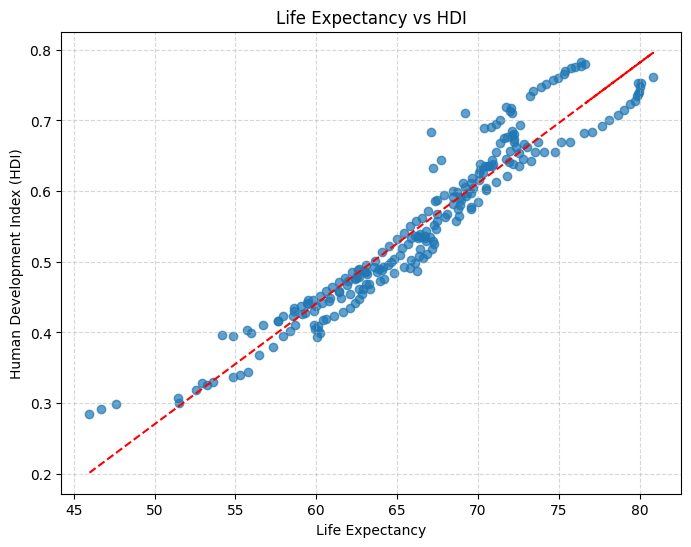

In [107]:
#  Prepare a clean subset for analyzing the relationship between life expectancy and HDI
subset = hdi_south_asia[['life_expectancy', 'hdi']].dropna()

# Create a scatter plot to visualize the association between life expectancy and HDI
plt.figure(figsize=(8, 6))
plt.scatter(subset['life_expectancy'], subset['hdi'], alpha=0.7)

#  Label axes and add a descriptive title
plt.xlabel('Life Expectancy')
plt.ylabel('Human Development Index (HDI)')
plt.title('Life Expectancy vs HDI')

# Fit and overlay a linear trend line to highlight the overall relationship
z = np.polyfit(subset['life_expectancy'], subset['hdi'], 1)
p = np.poly1d(z)
plt.plot(subset['life_expectancy'], p(subset['life_expectancy']), "r--")

# Add gridlines for improved readability
plt.grid(True, linestyle='--', alpha=0.5)

#  Display the visualization
plt.show()

# Explanation:
# The scatter plot illustrates a positive relationship between life expectancy
# and HDI, with the fitted trend line indicating that countries with higher
# life expectancy tend to achieve higher levels of human development.


Life expectancy and HDI show a strong positive relationship: as life expectancy increases, HDI also increases.
The upward-sloping trend line indicates that countries with longer lifespans tend to have higher levels of human development.

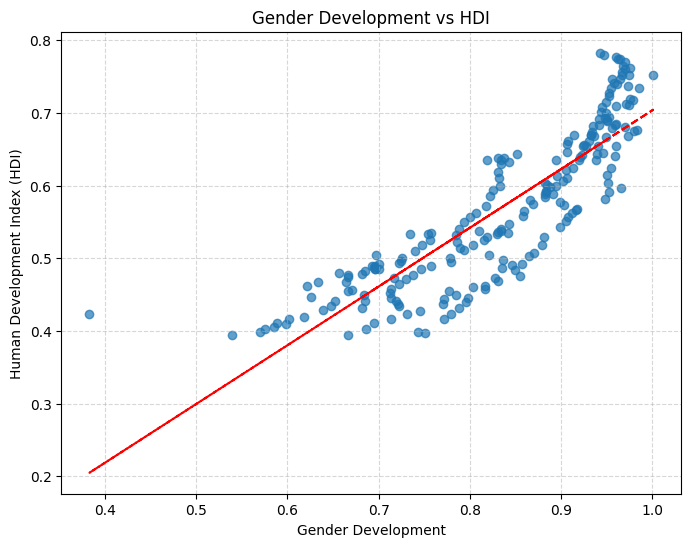

In [108]:
#  Create a subset to analyze the relationship between gender development and HDI
subset = hdi_south_asia[['gender_development', 'hdi']].dropna()

#  Generate a scatter plot to visualize the association
plt.figure(figsize=(8, 6))
plt.scatter(subset['gender_development'], subset['hdi'], alpha=0.7)

#Add axis labels and title
plt.xlabel('Gender Development')
plt.ylabel('Human Development Index (HDI)')
plt.title('Gender Development vs HDI')

# Fit and overlay a linear regression line
z = np.polyfit(subset['gender_development'], subset['hdi'], 1)
p = np.poly1d(z)
plt.plot(subset['gender_development'], p(subset['gender_development']), "r--")

#  Add gridlines for improved readability
plt.grid(True, linestyle='--', alpha=0.5)

#  Display the visualization
plt.show()

# Interpretation:
# Among South Asian countries, life expectancy exhibits a stronger association
# with HDI compared to gender development. While gender development is positively
# related to HDI, the relationship appears weaker, suggesting that variations in
# health outcomes play a more prominent role in explaining HDI differences.


The plot shows a clear positive relationship between Gender Development Index (GDI) and Human Development Index (HDI).
Countries with higher gender development tend to have higher overall human development.

In [109]:
#AnalysGapis
# Isolate South Asian countries for the year 2022
hdi_south_asia_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022]

#  Retain relevant variables and remove missing observations
hdi_south_asia_2022 = hdi_south_asia_2022[
    ['country', 'gross_inc_percap', 'hdi']
].dropna()

#  Compute the gap between income per capita and HDI values
hdi_south_asia_2022['gni_hdi_gap'] = (
    hdi_south_asia_2022['gross_inc_percap'] -
    hdi_south_asia_2022['hdi']
)

#  Rank countries by the magnitude of the income–HDI gap
gap_desc = hdi_south_asia_2022.sort_values(
    by='gni_hdi_gap', ascending=False
)

gap_desc

# Explanation:
# The income–HDI gap highlights disparities between economic wealth and overall
# human development. Larger gaps suggest that higher income levels are not
# proportionally reflected in HDI outcomes.


,country,gross_inc_percap,hdi,gni_hdi_gap
3530,Maldives,18846.792190,0.762,18846.030190
5477,Sri Lanka,11899.498470,0.780,11898.718470
659,Bhutan,10624.873880,0.681,10624.192880
2573,India,6950.526798,0.644,6949.882798
461,Bangladesh,6511.122178,0.670,6510.452178
4388,Pakistan,5374.270423,0.540,5373.730423
4091,Nepal,4025.554685,0.601,4024.953685
32,Afghanistan,1335.205733,0.462,1334.743733


In [110]:
#  Sort South Asian countries by the smallest income–HDI gap
gap_asc = hdi_south_asia_2022.sort_values(
    by='gni_hdi_gap', ascending=True
)

gap_asc

# Interpretation:
# Countries with smaller income–HDI gaps demonstrate a closer alignment between
# economic resources and human development outcomes. This suggests more effective
# translation of income into health, education, and overall well-being.


,country,gross_inc_percap,hdi,gni_hdi_gap
32,Afghanistan,1335.205733,0.462,1334.743733
4091,Nepal,4025.554685,0.601,4024.953685
4388,Pakistan,5374.270423,0.540,5373.730423
461,Bangladesh,6511.122178,0.670,6510.452178
2573,India,6950.526798,0.644,6949.882798
659,Bhutan,10624.873880,0.681,10624.192880
5477,Sri Lanka,11899.498470,0.780,11898.718470
3530,Maldives,18846.792190,0.762,18846.030190


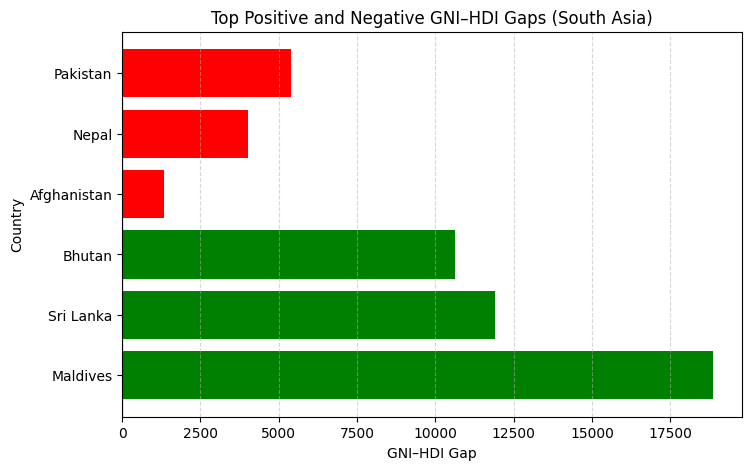

In [111]:
#  Sort South Asian countries by the smallest income–HDI gap
gap_asc = hdi_south_asia_2022.sort_values(
    by='gni_hdi_gap', ascending=True
)

gap_asc


#  Sort South Asian countries by the largest income–HDI gap
gap_desc = hdi_south_asia_2022.sort_values(
    by='gni_hdi_gap', ascending=False
)

gap_desc


# Select the top 3 countries with the highest and lowest gaps
top_positive = gap_desc.head(3)
top_negative = gap_asc.head(3)


# Combine extreme gap values into one dataset
plot_data = pd.concat([top_positive, top_negative])


#  Define color scheme for positive and negative gaps
colors = ['green'] * len(top_positive) + ['red'] * len(top_negative)


#  Visualize GNI–HDI gap comparison
plt.figure(figsize=(8,5))
plt.barh(plot_data['country'], plot_data['gni_hdi_gap'], color=colors)

# Zero reference line
plt.axvline(0, color='black', linewidth=0.8)

# Axis labels and chart title
plt.xlabel('GNI–HDI Gap')
plt.ylabel('Country')
plt.title('Top Positive and Negative GNI–HDI Gaps (South Asia)')

# Improve readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()


#  Interpretation
# The GNI–HDI gap highlights the difference between economic capacity
# and human development outcomes. Countries with larger positive gaps
# indicate that income growth does not always directly translate into
# better human well-being, while negative gaps suggest relatively strong
# human development despite lower income levels.


The chart shows that Maldives, Sri Lanka, and Bhutan have the largest positive GNI–HDI gaps, indicating income levels higher than HDI would suggest.
Pakistan, Nepal, and Afghanistan show negative gaps, meaning their HDI is relatively higher compared to their income levels.

In [112]:
# PROBLEM 3
# Comparative Regional Analysis: South Asia vs Middle East


#1 Create Middle East Subset
# Load the cleaned HDI dataset used in Problem 1B
hdi = pd.read_csv("HDI_problem1B.csv")

# Define country lists for South Asia and the Middle East
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

#  Filter the dataset to include only the years 2020–2022
hdi_2020_2022 = hdi[hdi['year'].isin([2020, 2021, 2022])]

# Create regional subsets for South Asia and the Middle East
hdi_south_asia = hdi_2020_2022[hdi_2020_2022['country'].isin(south_asia_countries)]
hdi_middle_east = hdi_2020_2022[hdi_2020_2022['country'].isin(middle_east_countries)]

#  Save the regional datasets for further comparison and analysis
hdi_south_asia.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
hdi_middle_east.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)


In [113]:
#2. Descriptive Statistics

#  Load regional datasets created earlier
south_asia = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
middle_east = pd.read_csv("HDI_MiddleEast_2020_2022.csv")


# Calculate average HDI and variation for South Asia
sa_mean = south_asia['hdi'].mean()
sa_std = south_asia['hdi'].std()


#  Calculate average HDI and variation for the Middle East
me_mean = middle_east['hdi'].mean()
me_std = middle_east['hdi'].std()


#  Create a summary table for regional comparison
stats = pd.DataFrame({
    'Region': ['South Asia', 'Middle East'],
    'Mean HDI (2020–2022)': [sa_mean, me_mean],
    'HDI Standard Deviation (2020–2022)': [sa_std, me_std]
})

stats


#  Interpretation
# The results show that Middle Eastern countries have a higher
# average Human Development Index compared to South Asian countries
# over the 2020–2022 period. Additionally, the larger standard deviation
# in the Middle East indicates greater diversity in development levels
# among countries in that region, whereas South Asia shows more
# clustered HDI values.


,Region,Mean HDI (2020–2022),HDI Standard Deviation (2020–2022)
0,South Asia,0.639583,0.098273
1,Middle East,0.788909,0.141295


In [114]:
#3 Top and Bottom Performers
#Compute average HDI by country for South Asia and Middle East
sa_avg = south_asia.groupby('country')['hdi'].mean().reset_index()
me_avg = middle_east.groupby('country')['hdi'].mean().reset_index()


# Identify top and bottom performing countries in South Asia
sa_top_3 = sa_avg.sort_values('hdi', ascending=False).head(3)
sa_bottom_3 = sa_avg.sort_values('hdi', ascending=True).head(3)


#  Identify top and bottom performing countries in the Middle East
me_top_3 = me_avg.sort_values('hdi', ascending=False).head(3)
me_bottom_3 = me_avg.sort_values('hdi', ascending=True).head(3)


#  Combine results for comparative analysis
combined = pd.concat([
    sa_top_3.assign(region='South Asia', group='Top 3'),
    sa_bottom_3.assign(region='South Asia', group='Bottom 3'),
    me_top_3.assign(region='Middle East', group='Top 3'),
    me_bottom_3.assign(region='Middle East', group='Bottom 3')
])

combined


,country,hdi,region,group
7,Sri Lanka,0.780000,South Asia,Top 3
4,Maldives,0.750667,South Asia,Top 3
2,Bhutan,0.677667,South Asia,Top 3
0,Afghanistan,0.474333,South Asia,Bottom 3
6,Pakistan,0.537667,South Asia,Bottom 3
5,Nepal,0.595000,South Asia,Bottom 3
9,United Arab Emirates,0.932667,Middle East,Top 3
2,Israel,0.910667,Middle East,Top 3
0,Bahrain,0.885333,Middle East,Top 3
10,Yemen,0.426333,Middle East,Bottom 3


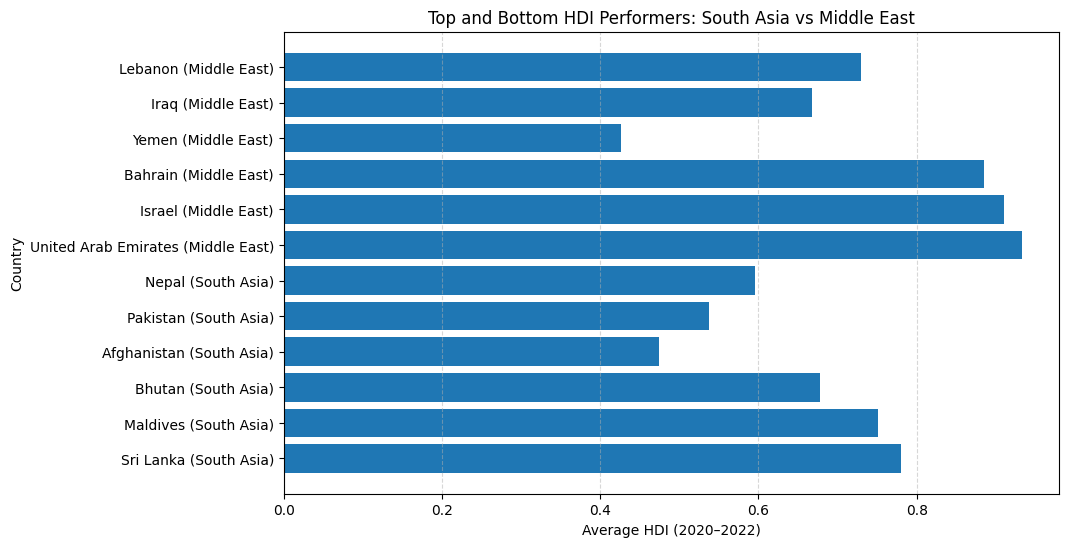

In [115]:
# Visualize average HDI for top and bottom performers
plt.figure(figsize=(10,6))

# Create labels combining country and region names
labels = combined['country'] + " (" + combined['region'] + ")"

# Plot horizontal bar chart
plt.barh(labels, combined['hdi'])

# Axis labels and chart title
plt.xlabel('Average HDI (2020–2022)')
plt.ylabel('Country')
plt.title('Top and Bottom HDI Performers: South Asia vs Middle East')

# Improve readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()


In [116]:
# 4 Compare key development metrics across regions
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

#  Calculate average values of selected metrics for South Asia
sa_means = south_asia[metrics].mean()

#  Calculate average values of selected metrics for the Middle East
me_means = middle_east[metrics].mean()

#  Combine regional averages into a comparison table
comparison = pd.DataFrame({
    'South Asia': sa_means,
    'Middle East': me_means
})

comparison


,South Asia,Middle East
gender_development,0.881458,0.896545
life_expectancy,70.970083,75.855455
gross_inc_percap,7766.509931,37750.770520


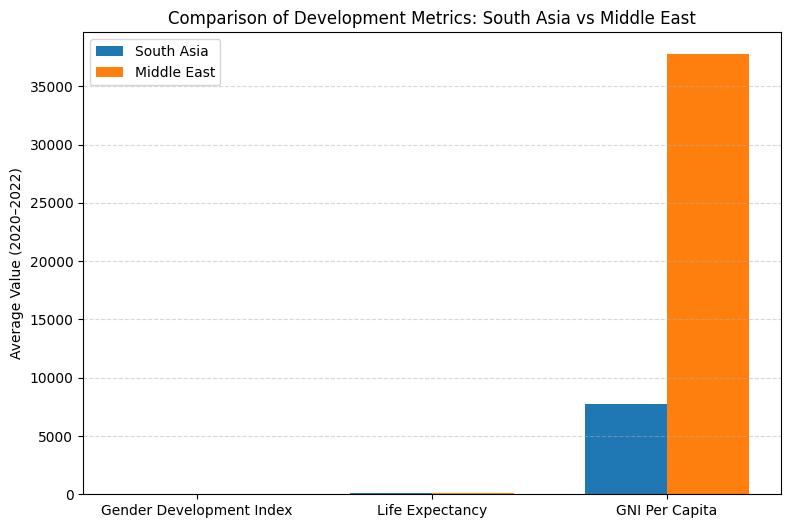

In [117]:
#Prepare positions for grouped bar chart
x = np.arange(len(metrics))
width = 0.35


#  Plot comparison of development metrics between regions
plt.figure(figsize=(9,6))
plt.bar(x - width/2, comparison['South Asia'], width, label='South Asia')
plt.bar(x + width/2, comparison['Middle East'], width, label='Middle East')


#  Define metric labels on x-axis
plt.xticks(x, [
    'Gender Development Index',
    'Life Expectancy',
    'GNI Per Capita'
])


#  Add chart labels, title, and legend
plt.ylabel('Average Value (2020–2022)')
plt.title('Comparison of Development Metrics: South Asia vs Middle East')
plt.legend()

# Improve visual clarity
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


#  Interpretation
# The chart shows noticeable differences between the two regions,
# with GNI per capita displaying the largest gap. This reflects the
# stronger economic position of Middle Eastern countries compared
# to South Asia, while differences in social indicators such as life
# expectancy and gender development are comparatively smaller.


In [118]:
#5-HDI Disparity
# Calculate HDI range for South Asia and Middle East
sa_range = south_asia['hdi'].max() - south_asia['hdi'].min()
me_range = middle_east['hdi'].max() - middle_east['hdi'].min()


#  Compute mean and standard deviation of HDI for South Asia
sa_mean = south_asia['hdi'].mean()
sa_std = south_asia['hdi'].std()
sa_cv = sa_std / sa_mean


#  Compute mean and standard deviation of HDI for the Middle East
me_mean = middle_east['hdi'].mean()
me_std = middle_east['hdi'].std()
me_cv = me_std / me_mean


#  Create a table summarizing HDI variability
variation_stats = pd.DataFrame({
    'Region': ['South Asia', 'Middle East'],
    'HDI Range': [sa_range, me_range],
    'HDI Coefficient of Variation': [sa_cv, me_cv]
})

variation_stats


#Interpretation
# The results show that the Middle East has a wider HDI range
# and a higher coefficient of variation compared to South Asia.
# This suggests greater inequality in human development levels
# among Middle Eastern countries, while South Asia displays
# relatively more uniform HDI outcomes.


,Region,HDI Range,HDI Coefficient of Variation
0,South Asia,0.321,0.153652
1,Middle East,0.513,0.179101


In [119]:
# 6- Correlation analysis

# Correlation between HDI and gender development
sa_corr_gender = south_asia['hdi'].corr(south_asia['gender_development'])
me_corr_gender = middle_east['hdi'].corr(middle_east['gender_development'])

# Correlation between HDI and life expectancy
sa_corr_life = south_asia['hdi'].corr(south_asia['life_expectancy'])
me_corr_life = middle_east['hdi'].corr(middle_east['life_expectancy'])


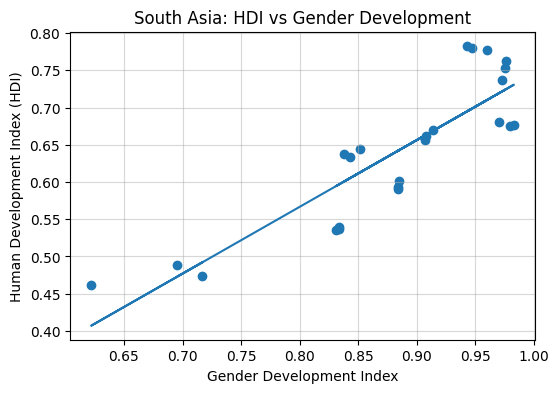

In [120]:
# Analyze relationship between gender development and HDI in South Asia
x = south_asia['gender_development']
y = south_asia['hdi']

# Remove missing values
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

# Fit linear regression line
m, b = np.polyfit(x, y, 1)

# Plot HDI against gender development
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, m * x + b)

plt.xlabel('Gender Development Index')
plt.ylabel('Human Development Index (HDI)')
plt.title('South Asia: HDI vs Gender Development')
plt.grid(alpha=0.5)
plt.show()


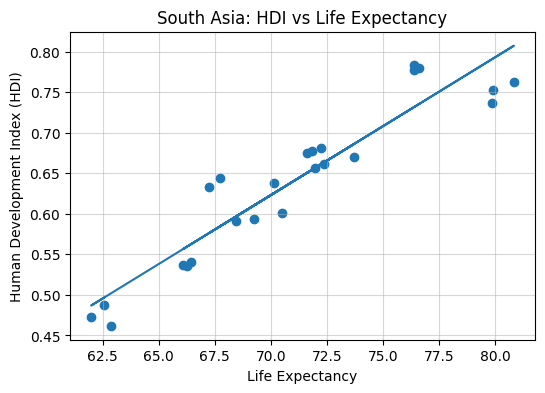

In [121]:
#  Analyze relationship between life expectancy and HDI in South Asia
x = south_asia['life_expectancy']
y = south_asia['hdi']

# Remove missing values
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

# Fit linear regression line
m, b = np.polyfit(x, y, 1)

# Plot HDI against life expectancy
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, m * x + b)

plt.xlabel('Life Expectancy')
plt.ylabel('Human Development Index (HDI)')
plt.title('South Asia: HDI vs Life Expectancy')
plt.grid(alpha=0.5)
plt.show()


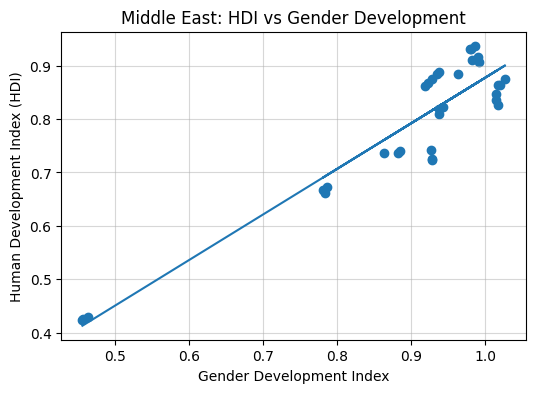

In [122]:
#  Analyze relationship between gender development and HDI in the Middle East
x = middle_east['gender_development']
y = middle_east['hdi']

# Remove missing values
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

# Fit linear regression line
m, b = np.polyfit(x, y, 1)

# Plot HDI against gender development
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, m * x + b)

plt.xlabel('Gender Development Index')
plt.ylabel('Human Development Index (HDI)')
plt.title('Middle East: HDI vs Gender Development')
plt.grid(alpha=0.5)
plt.show()


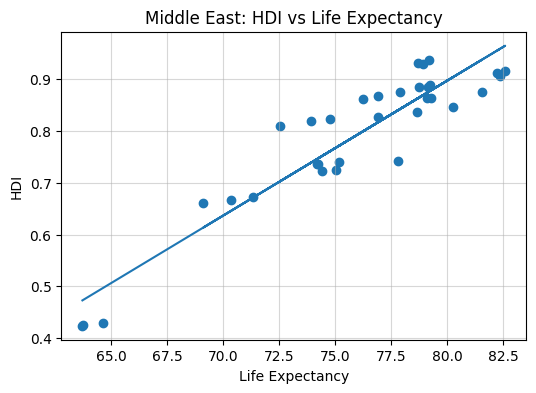

In [123]:
#  Analyze how life expectancy relates to HDI in Middle East countries
x = middle_east['life_expectancy']
y = middle_east['hdi']

# Remove missing values to ensure accurate correlation
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

# Fit a linear trend line
m, b = np.polyfit(x, y, 1)

# Plot the relationship
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, m * x + b)

# Label axes and title
plt.xlabel('Life Expectancy')
plt.ylabel('HDI')
plt.title('Middle East: HDI vs Life Expectancy')

# Improve readability
plt.grid(alpha=0.5)
plt.show()


In [124]:
# 7 Outlier detection for HDI and GNI per Capita (South Asia vs Middle East)

# Identify outliers in South Asia
south_asia['hdi_outlier'] = detect_outliers(south_asia['hdi'])
south_asia['gni_outlier'] = detect_outliers(south_asia['gross_inc_percap'])
south_asia['outlier'] = south_asia['hdi_outlier'] | south_asia['gni_outlier']

# Identify outliers in the Middle East
middle_east['hdi_outlier'] = detect_outliers(middle_east['hdi'])
middle_east['gni_outlier'] = detect_outliers(middle_east['gross_inc_percap'])
middle_east['outlier'] = middle_east['hdi_outlier'] | middle_east['gni_outlier']

# Interpretation:
# The IQR-based outlier detection identifies countries whose HDI or
# GNI per capita values deviate significantly from the regional norm.
# This helps highlight exceptional development patterns or economic
# disparities within South Asia and the Middle East.


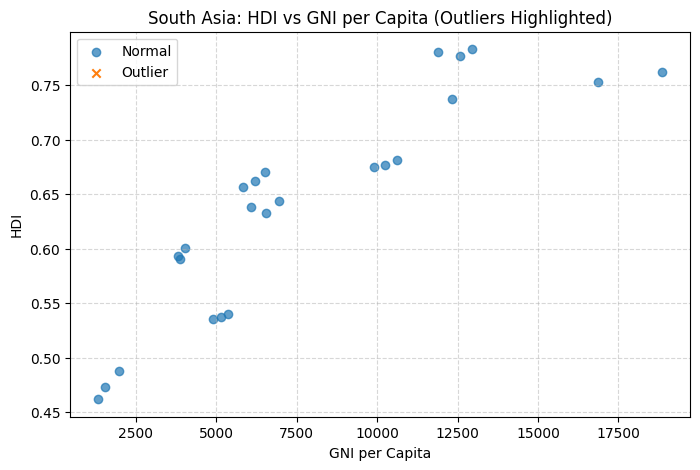

In [125]:
#  Visualize HDI vs GNI per capita with outliers highlighted (South Asia)
# Normal observations and detected outliers are plotted separately to
# clearly show whether extreme income or HDI values influence regional trends.

plt.figure(figsize=(8,5))

plt.scatter(
    south_asia.loc[~south_asia['outlier'], 'gross_inc_percap'],
    south_asia.loc[~south_asia['outlier'], 'hdi'],
    label='Normal',
    alpha=0.7
)

plt.scatter(
    south_asia.loc[south_asia['outlier'], 'gross_inc_percap'],
    south_asia.loc[south_asia['outlier'], 'hdi'],
    label='Outlier',
    marker='x'
)

plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('South Asia: HDI vs GNI per Capita (Outliers Highlighted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# The plot shows that most South Asian countries follow a positive
# relationship between income and HDI. No extreme outliers dominate
# the pattern, indicating relatively consistent development outcomes
# across the region.


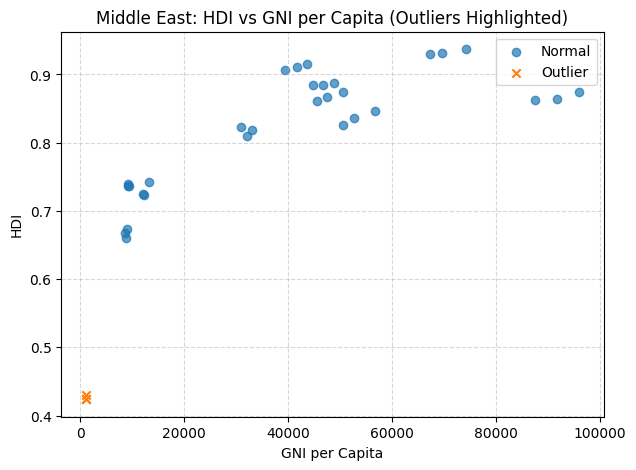

In [126]:
#  Visualize HDI vs GNI per capita with outliers highlighted (Middle East)
# This scatter plot separates normal observations and detected outliers
# to examine whether extreme income or HDI values influence regional patterns.

plt.figure(figsize=(7,5))

plt.scatter(
    middle_east.loc[~middle_east['outlier'], 'gross_inc_percap'],
    middle_east.loc[~middle_east['outlier'], 'hdi'],
    label='Normal',
    alpha=0.7
)

plt.scatter(
    middle_east.loc[middle_east['outlier'], 'gross_inc_percap'],
    middle_east.loc[middle_east['outlier'], 'hdi'],
    label='Outlier',
    marker='x'
)

plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('Middle East: HDI vs GNI per Capita (Outliers Highlighted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# The Middle East shows a strong positive association between income and HDI.
# A small number of outliers reflect countries with exceptionally high income
# levels or distinct development profiles, but the overall trend remains stable.
